In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Data (We use log returns)
data = yf.download('^JKSE', start='2005-01-01', end='2026-01-01', auto_adjust=True)
close = data['Close'].squeeze()
open = data['Open'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

momentum = returns.rolling(10).mean()

long_momentum =returns.rolling(30).mean()

overnight_gap = np.log(open / close.shift(1))

rolling_max = close.rolling(252).max()
drawdown = np.log(close / rolling_max)

#TESTER MAYBE REMOVE
volume = data['Volume'].squeeze()
volume_ma = volume.rolling(20).mean()
relative_volume = np.log(volume_ma / volume_ma.shift(1))

#Rolling volatility (20 day window) + Momentum (10 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol,
    'momentum': momentum,
    #'long_momentum': long_momentum,
    #'volume': relative_volume,
    #'open_close': overnight_gap
    'drawdown': drawdown
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head(20))

[*********************100%***********************]  1 of 1 completed

Data loaded: 4841 trading days
             returns  volatility  momentum  drawdown
Date                                                
2006-01-13 -0.004648    0.009965  0.007150 -0.008644
2006-01-16 -0.012208    0.010294  0.006059 -0.020851
2006-01-17 -0.018289    0.010590  0.003453 -0.039140
2006-01-18 -0.016354    0.011012  0.000715 -0.055494
2006-01-19  0.030427    0.012336  0.001504 -0.025067
2006-01-20 -0.005847    0.012481  0.000977 -0.030914
2006-01-23 -0.018788    0.013333 -0.001827 -0.049702
2006-01-24  0.005893    0.013364 -0.003086 -0.043809
2006-01-25  0.018789    0.013781 -0.002502 -0.025020
2006-01-26 -0.002820    0.013842 -0.002384 -0.027840
2006-01-27  0.002488    0.013842 -0.001671 -0.025352
2006-01-30  0.002122    0.013810 -0.000238 -0.023230
2006-02-01  0.006772    0.013793  0.002268 -0.016458
2006-02-02  0.002172    0.013659  0.004121 -0.014286
2006-02-03  0.000589    0.012813  0.001137 -0.013696
2006-02-06  0.001223    0.012805  0.001844 -0.012473
2006-02-07  0.0

In [3]:
split = int(len(features) * 0.7)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 3388 days
Test:  1453 days


In [4]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

model = GaussianHMM(n_components=3, covariance_type="full", n_iter=200, random_state=42)
model.fit(scaled_train)

print(f"Converged: {model.monitor_.converged}")

Converged: True


In [5]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[states == s].mean() for s in range(3)]
sorted_states = np.argsort(state_means)
state_labels = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Neutral',
    #sorted_states[2]: 'Weak Bull',
    sorted_states[2]: 'Bull'
}
colors = {
    sorted_states[0]: '#d62728',   # red
    sorted_states[1]: '#ffbb78',   # light orange
    #sorted_states[2]: '#aec7e8',   # light blue
    sorted_states[2]: "#3c902b",   # green
}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(3)})

State means: {'Bull': '0.0013', 'Neutral': '0.0000', 'Bear': '-0.0006'}


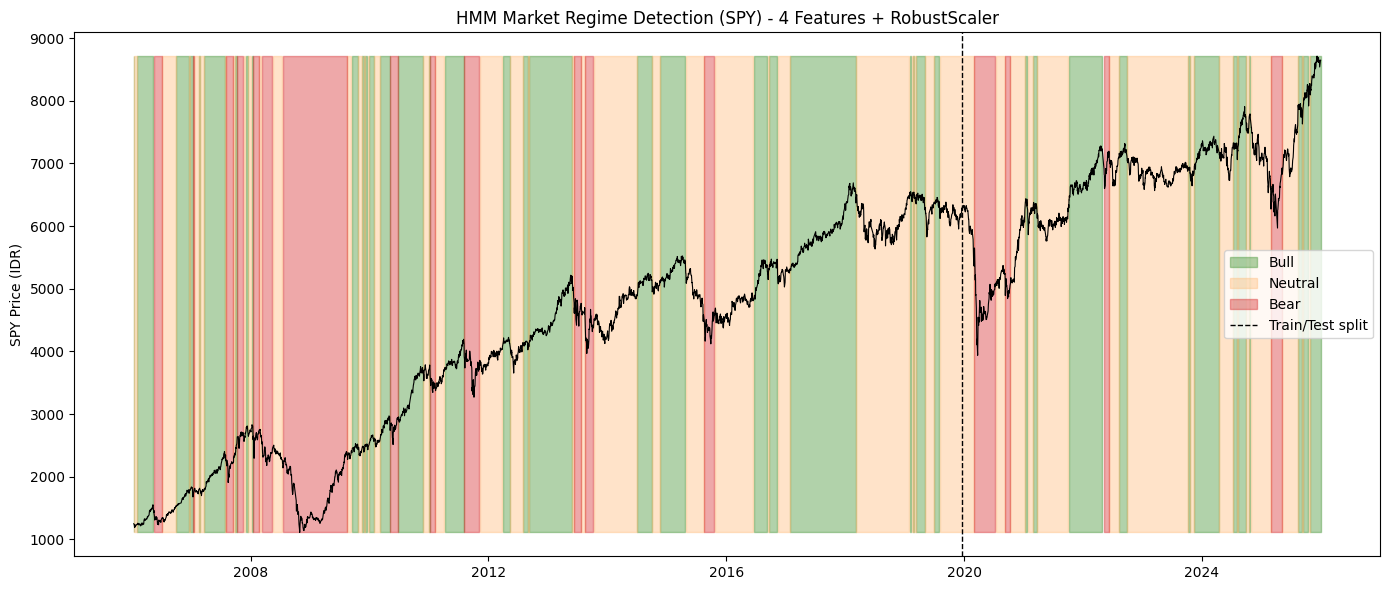

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(3):
    mask = (states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 4 Features + RobustScaler')
plt.ylabel('SPY Price (IDR)')
plt.tight_layout()
plt.show()

In [7]:
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Bull     | Mean: 0.0013 | Std: 0.0075 | Days: 1825
Neutral  | Mean: 0.0000 | Std: 0.0097 | Days: 2197
Bear     | Mean: -0.0006 | Std: 0.0228 | Days: 819


In [8]:
# Check if test set regimes look sane vs train set
test_states = model.predict(scaler.transform(test_features))

print("Train regime distribution:")
for state in range(3):
    pct = (states[:split] == state).sum() / split * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

print("\nTest regime distribution:")
for state in range(3):
    pct = (test_states == state).sum() / len(test_states) * 100
    print(f"  {state_labels[state]:12s}: {pct:.1f}%")

Train regime distribution:
  Bull        : 40.5%
  Neutral     : 40.3%
  Bear        : 19.2%

Test regime distribution:
  Bull        : 31.3%
  Neutral     : 57.1%
  Bear        : 11.6%


In [9]:
results = []

for n in range(2, 7):
    m = GaussianHMM(n_components=n, covariance_type="full", n_iter=200, random_state=42)
    m.fit(scaled_train)
    
    aic = m.aic(all_scaled)
    bic = m.bic(all_scaled)
    results.append((n, aic, bic))
    print(f"n={n} | AIC: {aic:.2f} | BIC: {bic:.2f} | Converged: {m.monitor_.converged}")

n=2 | AIC: 39594.12 | BIC: 39795.16 | Converged: True
n=3 | AIC: 33092.97 | BIC: 33417.21 | Converged: True
n=4 | AIC: 30977.06 | BIC: 31437.49 | Converged: True
n=5 | AIC: 28428.99 | BIC: 29038.57 | Converged: True
n=6 | AIC: 30023.72 | BIC: 30795.42 | Converged: True


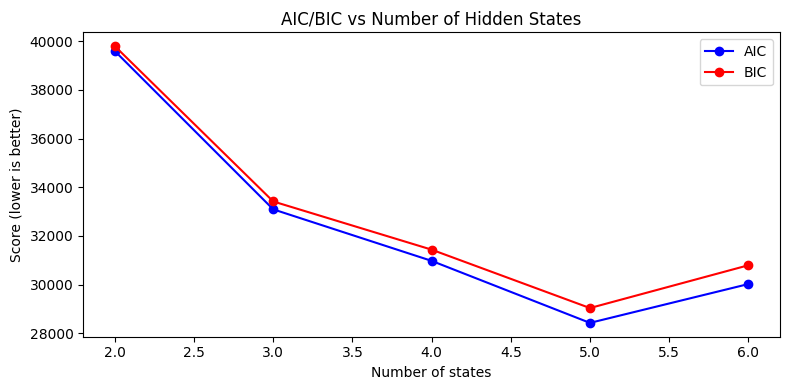

In [10]:
ns   = [r[0] for r in results]
aics = [r[1] for r in results]
bics = [r[2] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(ns, aics, 'o-', label='AIC', color='blue')
plt.plot(ns, bics, 'o-', label='BIC', color='red')
plt.xlabel('Number of states')
plt.ylabel('Score (lower is better)')
plt.title('AIC/BIC vs Number of Hidden States')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# State persistence — average days spent in each regime before switching
def compute_persistence(states, state_labels):
    persistence = {label: [] for label in state_labels.values()}
    
    current_state = states[0]
    count = 1
    
    for i in range(1, len(states)):
        if states[i] == current_state:
            count += 1
        else:
            persistence[state_labels[current_state]].append(count)
            current_state = states[i]
            count = 1
    
    # Don't forget the last run
    persistence[state_labels[current_state]].append(count)
    
    print("State Persistence (avg consecutive days per regime):")
    for label, runs in persistence.items():
        print(f"{label:12s} | Avg: {np.mean(runs):.1f} days | Max: {np.max(runs)} days | Transitions: {len(runs)}")

compute_persistence(states, state_labels)

State Persistence (avg consecutive days per regime):
Bear         | Avg: 48.2 days | Max: 257 days | Transitions: 17
Neutral      | Avg: 45.8 days | Max: 248 days | Transitions: 48
Bull         | Avg: 44.5 days | Max: 267 days | Transitions: 41


In [12]:
#log-likelihood on train vs test set
scaled_test = scaler.transform(test_features)

train_score = model.score(scaled_train) / len(scaled_train)
test_score = model.score(scaled_test) / len(scaled_test)

print(f"Train log-likelihood (per sample): {train_score:.4f}")
print(f"Test log-likelihood (per sample): {test_score:.4f}")
print(f"Difference: {abs(train_score - test_score):.4f}")

if abs(train_score - test_score) < 0.5:
    print("\nModel generalizes well - train and test scores are close")
elif test_score < train_score - 0.5:
    print("\nPossible overfitting — test score is significantly lower than train")

Train log-likelihood (per sample): -3.4779
Test log-likelihood (per sample): -3.2527
Difference: 0.2252

Model generalizes well - train and test scores are close


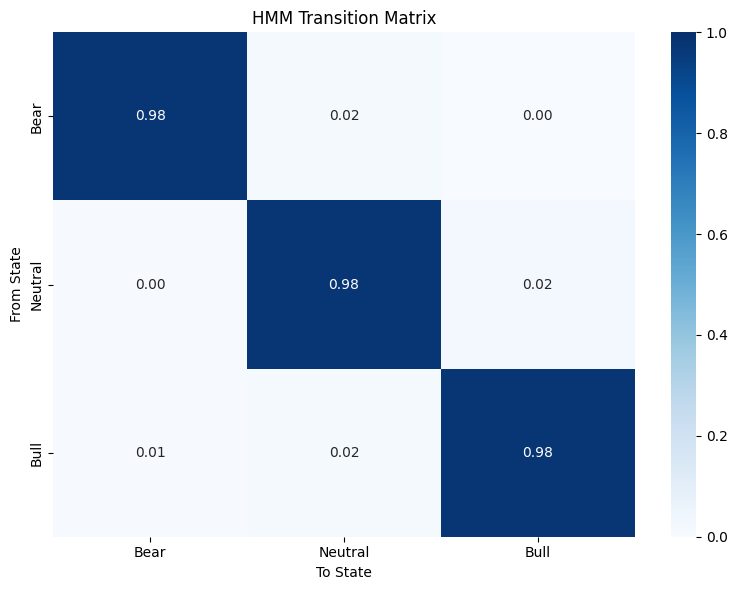

In [13]:
import seaborn as sns

# Get transition matrix and reorder by our state labels
# Build ordered label list from sorted_states
ordered_labels = [state_labels[sorted_states[i]] for i in range(3)]

# Reorder transition matrix rows/cols to match our labeling
transmat = model.transmat_

# Map sorted state indices to transition matrix
idx = [sorted_states[i] for i in range(3)]
reordered = transmat[np.ix_(idx, idx)]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(reordered, 
            annot=True, 
            fmt='.2f',
            xticklabels=ordered_labels,
            yticklabels=ordered_labels,
            cmap='Blues',
            vmin=0, vmax=1)

plt.title('HMM Transition Matrix')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()
plt.show()

In [14]:
# Regime Prediction using forward algorithm + transition matrix
def predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=1):
    # Scale the recent data
    scaled = scaler.transform(recent_data)

    # Forward algorithm - get current state probability distribution
    # model.predict_proba() returns P(state|observations) for each timestep
    state_probs = model.predict_proba(scaled)

    # Take the last timestep's probabilities as current state
    current_probs = state_probs[-1]

    # Project k steps ahead using the transition matrix
    future_probs = current_probs @ np.linalg.matrix_power(model.transmat_, k)

    #Map to labels
    predicted_state = np.argmax(future_probs)
    predicted_label = state_labels[predicted_state]

    print(f"Prediction {k} day(s) ahead:")
    print(f"Predicted regime: {predicted_label}")
    print(f"\nFull probability distribution:")
    for i in range(3):
        label = state_labels[sorted_states[i]]
        prob = future_probs[sorted_states[i]]
        print(f"  {label:.12s}: {prob:.4f} ({prob*100:.4f}%)")

    return predicted_label, future_probs

#Use last 60 days as recent data
recent_data = features.iloc[-60:]

#Predict 1, 5, 10 days ahead
for k in [1, 5, 10]:
    print(f"{'='*40}")
    predict_regime(model, recent_data, scaler, state_labels, sorted_states, k=k)
    print()

Prediction 1 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0050 (0.5037%)
  Neutral: 0.0167 (1.6692%)
  Bull: 0.9783 (97.8271%)

Prediction 5 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0239 (2.3888%)
  Neutral: 0.0761 (7.6058%)
  Bull: 0.9001 (90.0054%)

Prediction 10 day(s) ahead:
Predicted regime: Bull

Full probability distribution:
  Bear: 0.0448 (4.4791%)
  Neutral: 0.1377 (13.7705%)
  Bull: 0.8175 (81.7503%)



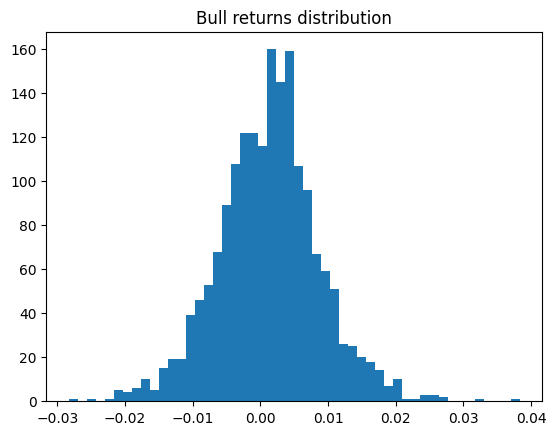

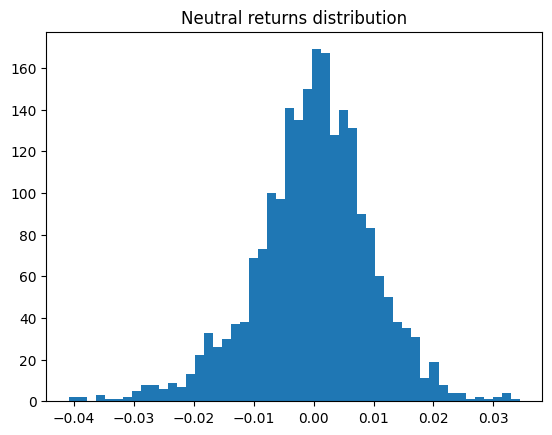

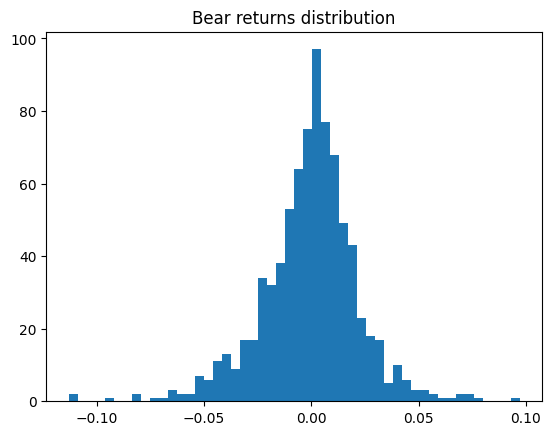

In [15]:
# Check if returns within each state look Gaussian
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    plt.hist(regime_returns, bins=50)
    plt.title(f'{state_labels[state]} returns distribution')
    plt.show()

In [16]:
def walk_forward_hmm(features, n_splits=5, n_components=3):
    total = len(features)
    fold_size = total // (n_splits + 1)
    
    results = []
    for i in range(1, n_splits + 1):
        train = features.iloc[:fold_size * i]
        test = features.iloc[fold_size * i : fold_size * (i + 1)]
        
        scaler = RobustScaler()
        scaled_train = scaler.fit_transform(train)
        scaled_test = scaler.transform(test)
        
        model = GaussianHMM(n_components=n_components, 
                           covariance_type="full", 
                           n_iter=200, 
                           random_state=42)
        model.fit(scaled_train)
        
        train_score = model.score(scaled_train) / len(scaled_train)
        test_score = model.score(scaled_test) / len(scaled_test)
        
        print(f"Fold {i} | Train: {len(train)} days | "
              f"Test: {len(test)} days | "
              f"Train LL: {train_score:.4f} | "
              f"Test LL: {test_score:.4f} | "
              f"Gap: {abs(train_score-test_score):.4f}")
        results.append((train_score, test_score))
    
    avg_gap = np.mean([abs(r[0]-r[1]) for r in results])
    print(f"\nAverage gap across folds: {avg_gap:.4f}")
    return results

results = walk_forward_hmm(features, n_splits=5, n_components=3)

Fold 1 | Train: 806 days | Test: 806 days | Train LL: -3.1039 | Test LL: -1.7388 | Gap: 1.3651
Fold 2 | Train: 1612 days | Test: 806 days | Train LL: -3.3511 | Test LL: -2.9181 | Gap: 0.4331
Fold 3 | Train: 2418 days | Test: 806 days | Train LL: -3.3421 | Test LL: -2.2197 | Gap: 1.1224
Fold 4 | Train: 3224 days | Test: 806 days | Train LL: -3.4172 | Test LL: -3.6669 | Gap: 0.2497
Fold 5 | Train: 4030 days | Test: 806 days | Train LL: -3.5594 | Test LL: -2.7990 | Gap: 0.7603

Average gap across folds: 0.7861
